In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns 

In [3]:
df=pd.read_csv("diamonds.csv")
df

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


C:\Users\HP\anaconda3\lib\site-packages\seaborn\distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


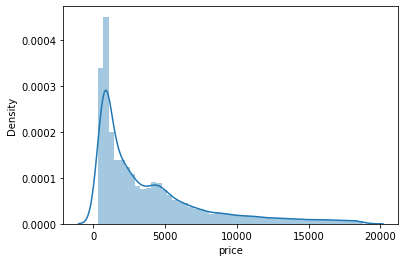

In [45]:
sns.distplot(df["price"])

In [4]:
df.isnull().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

### Uni variate Analysis 

In [49]:
num_features = df.select_dtypes(include=['int64','float64'])
print(num_features.columns)

Index(['carat', 'depth', 'table', 'price', 'x', 'y', 'z'], dtype='object')


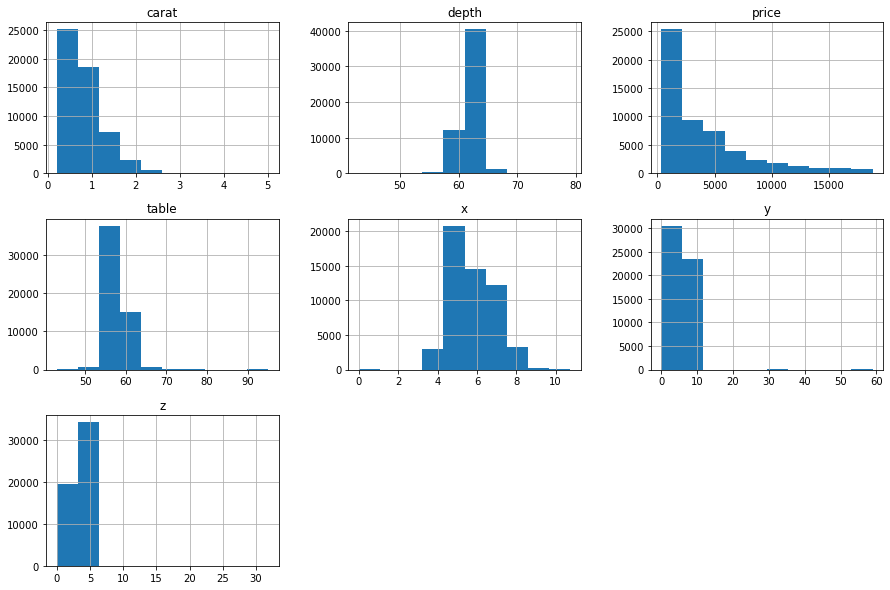

In [50]:
num_features.hist(figsize=(15,10));

### Preprocessing the data

#### Encoding the categorical variables
1. labelencoding
2. onehotencoding
3. get_dummies
4. binaryencoding

In [5]:
data=df.copy()

In [6]:
df_d=pd.get_dummies(data,drop_first=True)

In [7]:
df_d

,carat,depth,table,price,x,y,z,cut_Good,cut_Ideal,cut_Premium,...,color_H,color_I,color_J,clarity_IF,clarity_SI1,clarity_SI2,clarity_VS1,clarity_VS2,clarity_VVS1,clarity_VVS2
0,0.23,61.5,55.0,326,3.95,3.98,2.43,0,1,0,...,0,0,0,0,0,1,0,0,0,0
1,0.21,59.8,61.0,326,3.89,3.84,2.31,0,0,1,...,0,0,0,0,1,0,0,0,0,0
2,0.23,56.9,65.0,327,4.05,4.07,2.31,1,0,0,...,0,0,0,0,0,0,1,0,0,0
3,0.29,62.4,58.0,334,4.20,4.23,2.63,0,0,1,...,0,1,0,0,0,0,0,1,0,0
4,0.31,63.3,58.0,335,4.34,4.35,2.75,1,0,0,...,0,0,1,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53935,0.72,60.8,57.0,2757,5.75,5.76,3.50,0,1,0,...,0,0,0,0,1,0,0,0,0,0
53936,0.72,63.1,55.0,2757,5.69,5.75,3.61,1,0,0,...,0,0,0,0,1,0,0,0,0,0
53937,0.70,62.8,60.0,2757,5.66,5.68,3.56,0,0,0,...,0,0,0,0,1,0,0,0,0,0
53938,0.86,61.0,58.0,2757,6.15,6.12,3.74,0,0,1,...,1,0,0,0,0,1,0,0,0,0


### Separating Independent Variables from dependent variables.
https://machinelearningmastery.com/standardscaler-and-minmaxscaler-transforms-in-python/

In [8]:
X=df_d.drop("price",axis=1)
Y=df_d["price"]

### Scaling the Features
https://machinelearningmastery.com/standardscaler-and-minmaxscaler-transforms-in-python/

In [9]:
from sklearn.preprocessing import StandardScaler

In [10]:
scaled_X=StandardScaler().fit_transform(X)


In [12]:
from sklearn.model_selection import train_test_split

https://www.kdnuggets.com/2020/05/dataset-splitting-best-practices-python.html

In [15]:
X_train,X_test,y_train,y_test=train_test_split(scaled_X, Y, test_size=0.25,random_state=42)

### Applying regression Models to dataset

### 1. Linear Regression

 Linear Regression is the basic form of regression analysis. 
 
**Goal :** we try to calculate the best fit line with minimum error, which describes the relationship between the predictors and predictive/dependent variable.

**Assumptions**: 
There are four assumptions associated with a linear regression model:


1. **Linearity:** The relationship between independent variables and the dependent variable is linear. 

     <font color="blue">- *_Detection:_*</font> scatterplots,correlation(pearson correlation).
     
     <font color="blue">- *_Fixing Violation:_*</font> by applying non_linear transformations like x2(in case of negative values),log(x)(only if values are positive),exp(x),sqrt(x).
     
 
2. **Homoscedasticity:** Homoskedastic (also spelled "homoscedastic") refers to a condition in which the variance of the residual, or error term, in a regression model is constant. That is, the error term does not vary much as the value of the predictor variable changes. Another way of saying this is that the variance of the data points are roughly the same for all data points. 

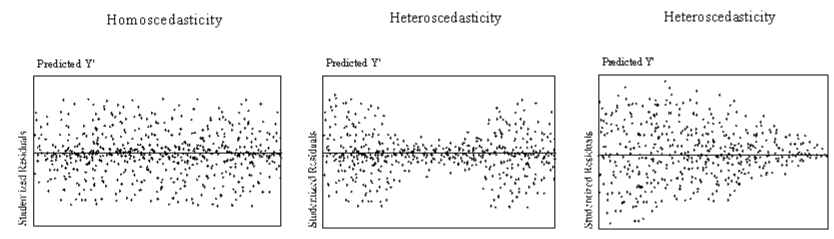

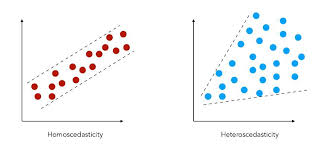




3. **Independence of Independent Variables**/**No Multilinearity**: Observations are independent of each other, there should be no correlation among the Independent variables.

     <font color="blue">-*_Detection:_*</font>
     
      1. Correlation Matix.
      2. Variance Inflation Factor.
      
      **Note**:In the presence of multicollinearity, the estimate of one variable's impact on the dependent variable $Y$ while controlling for the others tends to be less precise than if predictors were uncorrelated with one another. The usual interpretation of a regression coefficient is that it provides an estimate of the effect of a one unit change in an independent variable, $X_{{1}}$, holding the other variables constant. If $X_{{1}}$ is highly correlated with another independent variable, $X_{{2}}$, in the given data set, then we have a set of observations for which $X_{{1}}$ and $X_{{2}}$ have a particular linear stochastic relationship. We don't have a set of observations for which all changes in $X_{{1}}$ are independent of changes in $X_{{2}}$, so we have an imprecise estimate of the effect of independent changes in $X_{{1}}$.
      <font color="blue">_Fix Violations_</font>
      - remove all the redundant columns with high correlation among the independent variables.
      - check for vif, and vif=1, the columns are important, and the variables with vif within 2<if<5 have moderate                     correlation, vif>5 indicates high correlation.
      
         $$vif = \frac{1}{1-R^2}
         
         source:https://etav.github.io/python/vif_factor_python.html#:~:text=The%20Variance%20Inflation%20Factor%20(VIF,if%20it%20were%20fit%20alone.
      
      

4. **Normality of error terms:** There should be normality in residuals .
  - <font color="blue">*_Detection:_* </font>
      1. **QQ Plot** -The plot between the normal distribution vs the probability distributions of the residuals, the plot            should look linear, which indicates the assumption is satisfied.
      2. __Shapiro Wilk's test__:we can check the p_values of Shapiro wilk test.
      3. __Histogram Plot__
      
  - <font color="blue">*Fixing Violations_:*</font>
      1. Non_lineat transformations of variables.
      2. Remove outliers.
      
  - <font color="blue">*_Possible reason for violation_:*</font> violations of normality often arise either because 
    (a) the distributions of the dependent and/or independent variables are themselves significantly non-normal, and/or 
    (b) the linearity assumption is violated. 
    In such cases, a nonlinear transformation of variables might cure both problems.

5. **No Autocorrelation of errors/residuals**: There should be no correlation between the residual (error) terms. Absence of this phenomenon is known as Autocorrelation. In presence of autocorrelation of error terms it indicates that the resdiuals or error follow a pattern.
   <font color="blue".>*Detect_*: Durbin Watson Test.

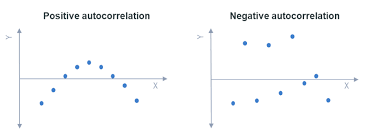
  

-https://www.mygreatlearning.com/blog/linear-regression-in-machine-learning/#:~:text=Linear%20regression%20is%20one%20of,call%20it%20Multiple%20Linear%20Regression.
- assumptions and violations:http://people.duke.edu/~rnau/testing.htm

### Performance of Regression
The performance of the regression model can be evaluated by using various metrics like MAE, MAPE, RMSE, R-squared etc.

__Mean Absolute Error (MAE):__ 
MAE measures the average magnitude of the errors in a set of predictions, without considering their direction. It’s the average over the test sample of the absolute differences between prediction and actual observation where all individual differences have equal weight.

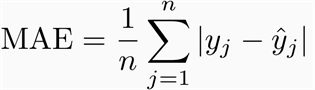
    
If the absolute value is not taken (the signs of the errors are not removed), the average error becomes the Mean Bias Error (MBE) and is usually intended to measure average model bias. MBE can convey useful information, but should be interpreted cautiously because positive and negative errors will cancel out.


__Mean Absolute Percentage Error (MAPE)__
MAPE is defined as the average of the absolute deviation of the predicted value from the actual value. It is the average of the ratio of the absolute difference between actual & predicted values, and actual value. 


M	=	mean absolute percentage error
n	=	number of times the summation iteration happens
A_t	=	actual value
F_t	=	forecast value

__Root Mean Square Error (RMSE)__
RMSE calculates the square root average of the sum of the squared difference between the actual and the predicted values.(RMSE) is the standard deviation of the residuals (prediction errors). Residuals are a measure of how far from the regression line data points are; When standardized observations and forecasts are used as RMSE inputs, there is a direct relationship with the correlation coefficient. For example, if the correlation coefficient is 1, the RMSE will be 0, because all of the points lie on the regression line (and therefore there are no errors).



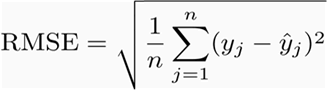

__R-squared values__
R-square value depicts the percentage of the variation in the dependent variable explained by the independent variable in the model. 




__RSS = Residual sum of squares:__ It is the measure of the difference between the expected and the actual output. A small RSS indicates a tight fit of the model to the data. It is also defined as follows: 


__TSS__ = Total sum of squares: It is the sum of errors of the data points from the mean of the response variable. 

R2 value ranges from 0 to 1. Higher the R-square value better the model. The value of R2 increases if we add more variables to the model irrespective of the variable contributing to the model or not. This is the disadvantage of using R2.

__Adjusted R-squared values__
The disadvantage of R2 is fixed by the Adjusted R2 value. Adjusted R2 value will improve only if the added variable is making a significant contribution to the model. Adjusted R2 value adds penalty in the model.
  
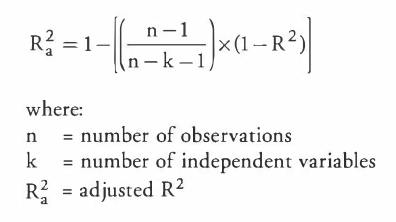

where R2 is R-square value, n = total number of observations, and k = total number of variables used in the model. If we increase the number of variables, the denominator becomes smaller and the overall ratio will be high. Subtracting from 1 will reduce the overall Adjusted R2. So to increase the Adjusted R2, the contribution of additive features to the model should be significantly high.


### Linear Regression ols method

!pip install lmdiag

In [54]:
import statsmodels.formula.api as sfa
import statsmodels.api as sa
import lmdiag

In [55]:
df_d.columns

Index(['carat', 'depth', 'table', 'price', 'x', 'y', 'z', 'cut_Good',
       'cut_Ideal', 'cut_Premium', 'cut_Very Good', 'color_E', 'color_F',
       'color_G', 'color_H', 'color_I', 'color_J', 'clarity_IF', 'clarity_SI1',
       'clarity_SI2', 'clarity_VS1', 'clarity_VS2', 'clarity_VVS1',
       'clarity_VVS2'],
      dtype='object')

In [59]:
df_d.rename(columns={'cut_Very Good':'cut_VeryGood'},inplace=True)

In [60]:
mod1_1=sfa.ols(formula='price~carat+depth+table+x+y+z+cut_Good+cut_Ideal+cut_Premium+cut_VeryGood+color_E+color_F+color_G+color_H+color_I+color_J+clarity_IF+clarity_SI1+clarity_SI2+clarity_VS1+clarity_VS2+clarity_VVS1+clarity_VVS2',data=df_d).fit()

In [61]:
mod1_1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.920
Model:                            OLS   Adj. R-squared:                  0.920
Method:                 Least Squares   F-statistic:                 2.688e+04
Date:                Wed, 24 Feb 2021   Prob (F-statistic):               0.00
Time:                        10:22:55   Log-Likelihood:            -4.5573e+05
No. Observations:               53940   AIC:                         9.115e+05
Df Residuals:                   53916   BIC:                         9.117e+05
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept     2184.4774    408.197      5.352      0.000    1384.409    2984.546
carat         1.126e+04     48.628    231.494      0.000    1.12e+04    1.14e+04
depth          -63.8061      4.535    -14.071      0.000     -72.694     -54.918
table          -26.4741      2.912     -9.092      0.000     -32.181     -20.767
x            -1008.2611     32.898    -30.648      0.000   -1072.741    -943.781
y                9.6089     19.333      0.497      0.619     -28.284      47.502
z              -50.1189     33.486     -1.497      0.134    -115.752      15.515
cut_Good       579.7514     33.592     17.259      0.000     513.911     645.592
cut_Ideal      832.9118     33.407     24.932      0.000     767.433     898.391
cut_Premium    762.1440     32.228     23.649      0.000     698.978     825.310
cut_VeryGood   726.7826     32.241     22.542      0.000     663.591     789.975
color_E       -209.1181     17.893    -11.687      0.000    -244.189    -174.047
color_F       -272.8538     18.093    -15.081      0.000    -308.316    -237.392
color_G       -482.0389     17.716    -27.209      0.000    -516.763    -447.315
color_H       -980.2667     18.836    -52.043      0.000   -1017.185    -943.348
color_I      -1466.2445     21.162    -69.286      0.000   -1507.723   -1424.766
color_J      -2369.3981     26.131    -90.674      0.000   -2420.615   -2318.181
clarity_IF    5345.1022     51.024    104.757      0.000    5245.095    5445.110
clarity_SI1   3665.4721     43.634     84.005      0.000    3579.949    3750.995
clarity_SI2   2702.5863     43.818     61.677      0.000    2616.702    2788.471
clarity_VS1   4578.3979     44.546    102.779      0.000    4491.087    4665.708
clarity_VS2   4267.2236     43.853     97.306      0.000    4181.270    4353.177
clarity_VVS1  5007.7590     47.160    106.187      0.000    4915.326    5100.192
clarity_VVS2  4950.8141     45.855    107.967      0.000    4860.938    5040.690
==============================================================================
Omnibus:                    14433.356   Durbin-Watson:                   1.183
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           565680.446
Skew:                           0.577   Prob(JB):                         0.00
Kurtosis:                      18.823   Cond. No.                     7.14e+03
==============================================================================

Warnings:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 7.14e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

- the summary shows that there is high multicollinearity

### Linear Regression model fitting

In [30]:
from sklearn.linear_model import LinearRegression

In [31]:
mod1=LinearRegression().fit(X_train,y_train)
pred1=mod1.predict(X_test)

In [32]:
mod1.coef_

array([ 5.32117849e+03, -9.24627830e+01, -5.96181941e+01, -1.10724404e+03,
       -4.81499482e+00, -2.45192355e+01,  1.67981166e+02,  4.15924195e+02,
        3.38178567e+02,  3.10029154e+02, -8.49319756e+01, -1.06660345e+02,
       -2.02408621e+02, -3.58654064e+02, -4.45556826e+02, -5.29149674e+02,
        9.71766604e+02,  1.59765262e+03,  1.03640880e+03,  1.65992079e+03,
        1.80871121e+03,  1.27542371e+03,  1.45994073e+03])

In [33]:
mod1.intercept_

3933.7585314502326

In [34]:
from sklearn import metrics

#### R_squared = TSS-SSR/TSS

In [41]:
metrics.r2_score(y_test,pred1)

0.9195675153810777

#### Adjusted r_2

In [42]:
print(1-(1-metrics.r2_score(y_test, pred1))*((len(X_test)-1)/(len(X_test)-len(X_test[0])-1)))

0.9194300852387232


#### Mean Absolute Error

In [37]:
metrics.mean_absolute_error(y_test,pred1)

735.7197347338587

#### Mean Squared Error

In [38]:
metrics.mean_squared_error(y_test,pred1)

1263569.548038798

#### Root Mean Squared Error

In [36]:
# RMSE
np.sqrt(metrics.mean_squared_error(y_test,pred1))

1124.086094584751

### Residual Analysis

C:\Users\HP\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


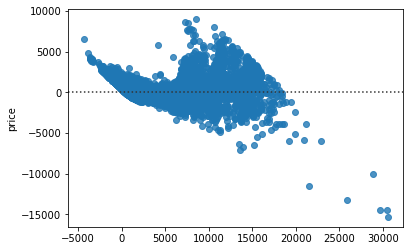

In [44]:
sns.residplot(pred, y_test)

C:\Users\HP\anaconda3\lib\site-packages\seaborn\distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


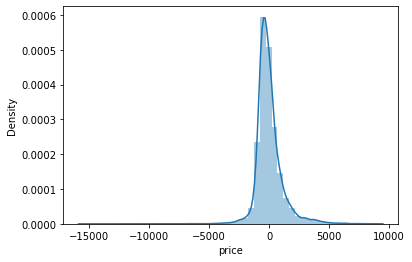

In [51]:
sns.distplot((y_test-pred),bins=50);

In [62]:
coeffecients = pd.DataFrame(mod1.coef_,X.columns)
coeffecients.columns = ['Coeffecient']
coeffecients

,Coeffecient
carat,5321.178495
depth,-92.462783
table,-59.618194
x,-1107.244039
y,-4.814995
z,-24.519235
cut_Good,167.981166
cut_Ideal,415.924195
cut_Premium,338.178567
cut_Very Good,310.029154


### 2. Polynomial

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
def polynomial_regression(degree,X_train,X_test,Y_train,Y_test):
    
    poly_reg = PolynomialFeatures(degree=degree)
    X_train_poly = poly_reg.fit_transform(X_train) # Converting X_train to given degree polynomial Equation
    prm = LinearRegression()
    prm.fit(X_train_poly,Y_train)
    y_pred_prm = prm.predict(X_train_poly)
    
    # Evaluation metrics for training dataset
    
    Y_train_pred = prm.predict(X_train_poly)
    rmse_train = np.sqrt(mean_squared_error(Y_train,Y_train_pred))
    Rsqr_train = round(r2_score(Y_train,Y_train_pred)*100,2)

    print('Evaluation metrics for Training Dataset')
    print('-'*40)
    print('RMSE is: ',rmse_train)
    print('RSquared is: '+str(Rsqr_train)+'%')

    print('\n')
    
    # Evaluation metrics for test dataset
    
    X_test_poly = poly_reg.fit_transform(X_test)
    Y_test_pred = prm.predict(X_test_poly)
    rmse_test =  np.sqrt(mean_squared_error(Y_test,Y_test_pred))
    Rsqr_test = round(r2_score(Y_test,Y_test_pred)*100,2)


    print('Evaluation metrics for Testing Dataset')
    print('-'*40)
    print('RMSE is: ',rmse_test)
    print('RSquared is: '+str(Rsqr_test)+'%')
    
    # return X_train_poly

### 3. K_NN

### 4. SVM

### 5. Decision Tree Regressor
https://gdcoder.com/decision-tree-regressor-explained-in-depth/
https://medium.com/pursuitnotes/decision-tree-regression-in-6-steps-with-python-1a1c5aa2ee16

In [63]:
from sklearn.tree import DecisionTreeRegressor
mod5 = DecisionTreeRegressor().fit(X_train,y_train)
mod5
pred5=mod5.predict(X_test)
print(metrics.r2_score(y_test,pred5))

0.9572381205702499


### Hyperparameter Tuning for Decision Tree

In [64]:
from sklearn.model_selection import GridSearchCV, cross_val_score, cross_val_predict
param_grid = {"criterion": ["mse", "mae"],
              "min_samples_split": [10, 20, 40],
              "max_depth": [2, 6, 8],
              "min_samples_leaf": [20, 40, 100],
              "max_leaf_nodes": [5, 20, 100],
              }


grid_cv5= GridSearchCV(mod5, param_grid, cv=5)

grid_cv5.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(),
             param_grid={'criterion': ['mse', 'mae'], 'max_depth': [2, 6, 8],
                         'max_leaf_nodes': [5, 20, 100],
                         'min_samples_leaf': [20, 40, 100],
                         'min_samples_split': [10, 20, 40]})

In [65]:
print("R-Squared for tuned model:{}".format(grid_cv5.best_score_))
print("Best Hyperparameters:\n{}".format(grid_cv5.best_params_))

R-Squared for tuned model:0.9397814016976908
Best Hyperparameters:
{'criterion': 'mse', 'max_depth': 8, 'max_leaf_nodes': 100, 'min_samples_leaf': 20, 'min_samples_split': 10}


### 6. RandomForestRegressor

### 5. Ada Boost

### 6. Gradient Boost

### 7. XGBoost

To-do:
    - check box-cox transformation
    - do train, test, validation 
    - residual analysis:https://medium.com/@dhwajraj/learning-python-regression-analysis-part-9-tests-and-validity-for-regression-models-78dcd5cde3a1
    
    https://www.jmp.com/en_in/statistics-knowledge-portal/what-is-multiple-regression/mlr-residual-analysis-and-outliers.html